In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,roc_auc_score,roc_curve,auc
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer


In [4]:
data = pd.read_csv('heart-disease-dataset.csv')

In [5]:
data.columns

Index(['age', 'sex', 'chest_pain_type', 'resting_bp_s', 'cholesterol',
       'fasting_blood_sugar', 'resting_ecg', 'max_heart_rate',
       'exercise_angina', 'oldpeak', 'st_slope', 'target'],
      dtype='object')

In [6]:
data.info

<bound method DataFrame.info of        age  sex  chest_pain_type  resting_bp_s  cholesterol  \
0     40.0  1.0              2.0         140.0        289.0   
1     49.0  0.0              3.0         160.0        180.0   
2     37.0  1.0              2.0         130.0        283.0   
3     48.0  0.0              4.0         138.0        214.0   
4     54.0  1.0              3.0         150.0        195.0   
...    ...  ...              ...           ...          ...   
1185  45.0  1.0              1.0         110.0        264.0   
1186  68.0  1.0              4.0         144.0        193.0   
1187  57.0  1.0              4.0         130.0        131.0   
1188  57.0  0.0              2.0         130.0        236.0   
1189  38.0  1.0              3.0         138.0        175.0   

      fasting_blood_sugar  resting_ecg  max_heart_rate  exercise_angina  \
0                     0.0          0.0           172.0              0.0   
1                     0.0          0.0           156.0       

In [7]:
pd.isna(data).sum()

age                    0
sex                    0
chest_pain_type        0
resting_bp_s           0
cholesterol            0
fasting_blood_sugar    0
resting_ecg            0
max_heart_rate         0
exercise_angina        0
oldpeak                0
st_slope               0
target                 0
dtype: int64

In [8]:
categorical_cols =['sex','chest_pain_type','fasting_blood_sugar','resting_ecg','exercise_angina','st_slope']
numerical_cols = ['age','resting_bp_s','cholesterol','max_heart_rate','oldpeak']

*creating preprocessing pipelines for both numeric and categorical data*

In [11]:
numeric_transformer = Pipeline(steps=[
                      ('scaler',StandardScaler())
])

categorical_transformer = Pipeline(steps=[
                         ('onehot',OneHotEncoder(handle_unknown = 'ignore'))
])


preprocessor = ColumnTransformer(transformers = [
                                ('num',numeric_transformer,numerical_cols),
                                ('cat',categorical_transformer,categorical_cols)
])


*define features and target*

In [13]:
X = data.drop('target',axis = 1)
y = data['target']

*split data*

In [14]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

create and train Logistic regression model

In [21]:
model = Pipeline(steps=[
                 ('preprocessor',preprocessor),
                 ('classifier',LogisticRegression(max_iter = 2000))
])

Define the Hyperparameter grid

In [22]:
param_grid = {'classifier__C':[0.01,0.1,1,10,100],
              'classifier__solver': ['liblinear','saga']}

setup gridsearch cv

In [23]:
grid_search = GridSearchCV(model,param_grid,cv = 5,scoring = 'accuracy')

In [24]:
grid_search.fit(X_train,y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('scaler',
                                                                                          StandardScaler())]),
                                                                         ['age',
                                                                          'resting_bp_s',
                                                                          'cholesterol',
                                                                          'max_heart_rate',
                                                                          'oldpeak']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['sex',
                                                                          'chest_pain_type',
                                                                          'fasting_blood_sugar',
                                                                          'resting_ecg',
                                                                          'exercise_angina',
                                                                          'st_slope'])])),
                                       ('classifier',
                                        LogisticRegression(max_iter=2000))]),
             param_grid={'classifier__C': [0.01, 0.1, 1, 10, 100],
                         'classifier__solver': ['liblinear', 'saga']},
             scoring='accuracy')

best parameters

In [26]:
print("Best Parameters:",grid_search.best_params_)

Best Parameters: {'classifier__C': 0.1, 'classifier__solver': 'liblinear'}


In [32]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
print("Accuracy: ",accuracy_score(y_test,y_pred))
print("Confusion Matrix: ",confusion_matrix(y_test,y_pred))
print("Classification Report: ",classification_report(y_test,y_pred))
print("ROC AUC Score: ",roc_auc_score(y_test,y_pred))

Accuracy:  0.8697478991596639
Confusion Matrix:  [[ 90  17]
 [ 14 117]]
Classification Report:                precision    recall  f1-score   support

         0.0       0.87      0.84      0.85       107
         1.0       0.87      0.89      0.88       131

    accuracy                           0.87       238
   macro avg       0.87      0.87      0.87       238
weighted avg       0.87      0.87      0.87       238

ROC AUC Score:  0.8671256331597346


plot the confusion matix heatmap

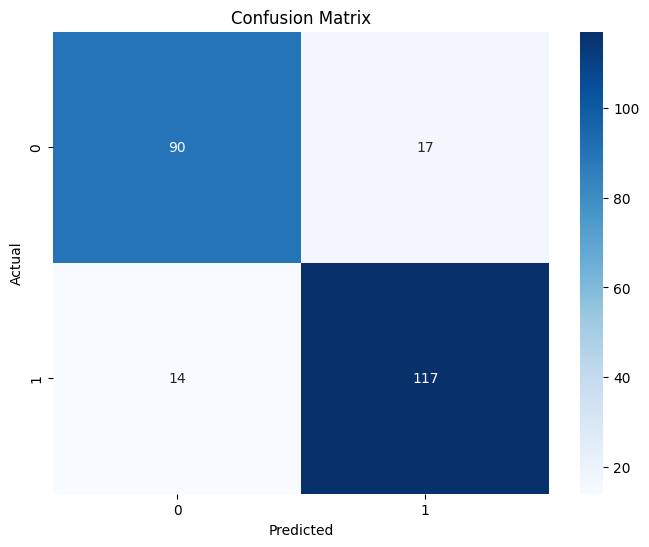

In [34]:
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test,y_pred),annot = True,fmt = 'd',cmap = 'Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

ROC Curve

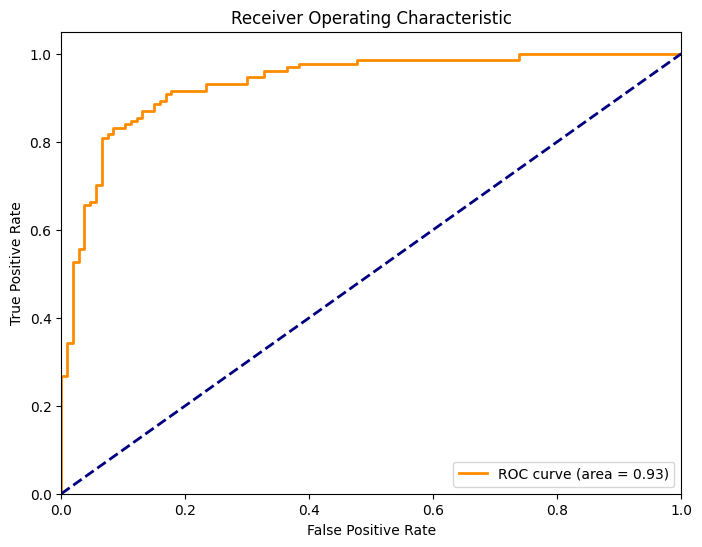

In [39]:
y_pred_proba = best_model.predict_proba(X_test)[:,1]
fpr,tpr, _ = roc_curve(y_test,y_pred_proba)
roc_auc = auc(fpr,tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,color = 'darkorange',lw = 2,label = 'ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0,1],[0,1],color = 'navy',lw = 2,linestyle = '--')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()